\Users\wzimm\Desktop
D:1B34342E_20260510\15\1B34342E_20260510_153900.bin
D:1B34342E_20260510\15\1B34342E_20260510_153900.bin fs= 96000 nch= 1 nbits= 32 pcm= 1
1 20 12 1024
96000 60.0


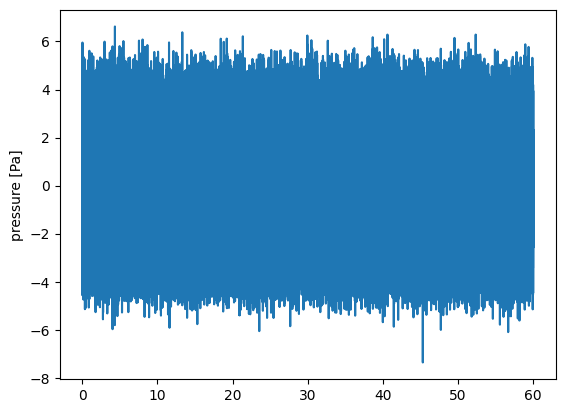

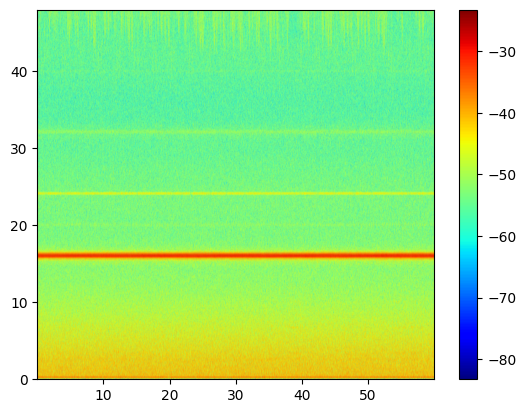

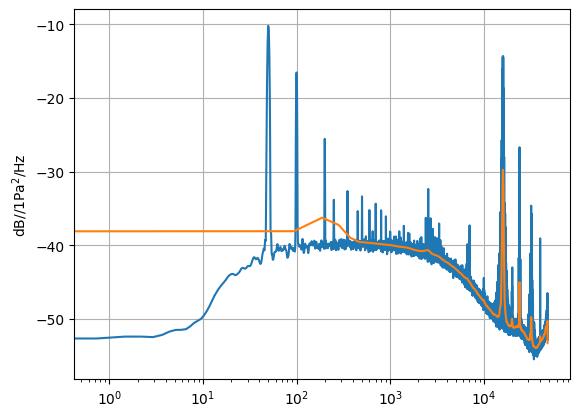

In [ ]:
import os

root=os.path.join(os.environ['HOMEPATH'],'Desktop') # for windows
print(root)
#
fname=os.path.join(root,'microPAM_data','1B7D3C2E_20260304','00',
                   '1B7D3C2E_20260304_000200.bin')
#
fname=os.path.join(root,'1B30112D_20260102_212400.bin')
fname=os.path.join('D:','135B2326_20260201','10','135B2326_20260201_104600.bin')
#
"D:\1B34342E_20260510\13\1B34342E_20260510_130043.wav"
"D:\1B34342E_20260510\12\1B34342E_20260510_122200.wav"
"D:\1B34342E_20260510\15\1B34342E_20260510_150100.wav"
"D:\1B34342E_20260510\15\1B34342E_20260510_153900.bin"
fname=os.path.join('D:','1B34342E_20260510','15','1B34342E_20260510_153900.bin')

print(fname)

import numpy as np
import microPAM as pam
fs,data = pam.load_microPAM(fname,True)
td = np.arange(data.shape[0])/fs
print(fs,data.shape[0]/fs)

# calibrate data
sens=-86 # dB//1V/Pa         # assume 1 Pa generates 50 E-6 V (10**(-86/20)) (sensitivity -206 dB//1V/uPa)
data /= 10**(sens/20)

ich=0 # selected channel
data=data[:,ich]

# plot time series
import matplotlib.pyplot as plt
plt.plot(td,data)
plt.ylabel('pressure [Pa]')
plt.show()

# plot spectrogram
import scipy.signal as signal
nw=512
f,t,q=signal.spectrogram(data,fs=fs,window='hann',nperseg=nw,noverlap=nw//2,nfft=nw*2,scaling='density')

Q=10*np.log10(np.abs(q))
qmax=np.max(Q)

ext=[t[0],t[-1],f[0]/1000,f[-1]/1000]
clim=[qmax-60,qmax]
#
plt.imshow(Q, aspect='auto',origin='lower', extent=ext,cmap='jet',clim=clim)
plt.colorbar()
plt.show()

# plot average power spectral density
nw=64*1024
fw,qw=signal.welch(data,fs=fs,window='hann',nperseg=nw,noverlap=nw//2,nfft=nw*2,scaling='density')
#

qu=np.mean(q,axis=1)
fu=f.copy()

plt.plot(fw,10*np.log10(qw))
plt.plot(fu,10*np.log10(qu))
plt.ylabel('dB//1Pa$^2$/Hz')
plt.xscale('log')
plt.grid(True)
plt.show()
